In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("/content/heart_failure_clinical_records_dataset-selected-columns.csv")

In [3]:
df.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1


In [4]:
df.shape

(299, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(9)
memory usage: 28.2 KB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [9]:
X_scaled = pd.DataFrame(X_scaled,columns=df.columns)
X_scaled.head()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT
0,1.192945,-0.871105,0.000166,-0.847579,-1.530560,1.359272,1.681648e-02,0.490057,-1.504036,0.735688,-0.687682,1.454161
1,-0.491279,-0.871105,7.514640,-0.847579,-0.007077,-0.735688,7.535660e-09,-0.284552,-0.141976,0.735688,-0.687682,1.454161
2,0.350833,-0.871105,-0.449939,-0.847579,-1.530560,-0.735688,-1.038073e+00,-0.090900,-1.731046,0.735688,1.454161,1.454161
3,-0.912335,1.147968,-0.486071,-0.847579,-1.530560,-0.735688,-5.464741e-01,0.490057,0.085034,0.735688,-0.687682,1.454161
4,0.350833,1.147968,-0.435486,1.179830,-1.530560,-0.735688,6.517986e-01,1.264666,-4.682176,-1.359272,-0.687682,1.454161


In [25]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(X_scaled)
  wcss.append(kmeans.inertia_)

In [26]:
wcss

[3588.0000000000014,
 3214.6373024750483,
 2935.7752663379506,
 2840.276096574342,
 2679.0736135329707,
 2496.538401717073,
 2402.200477482771,
 2335.3220238625804,
 2253.288717377549,
 2181.1292439863228]

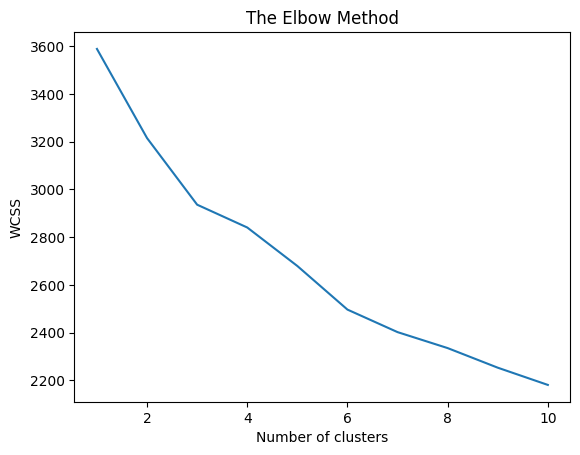

In [27]:
import matplotlib.pyplot as plt # helps finding 'k'.
plt.plot(range(1,11),wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [28]:
from sklearn.metrics import silhouette_score # Helps to evaluate 'k'.
for k in range(2,9):
    kmeans = KMeans(n_clusters= k, random_state = 42, n_init = 10)
    labels = kmeans.fit_predict(X_scaled)
    sil_score = silhouette_score(X_scaled, labels)
    print(f"Silhouette Score for k = {k}: {sil_score}")

Silhouette Score for k = 2: 0.14626319728707454
Silhouette Score for k = 3: 0.1033567277750737
Silhouette Score for k = 4: 0.11998853470675518
Silhouette Score for k = 5: 0.10125328924731462
Silhouette Score for k = 6: 0.11193648516864263
Silhouette Score for k = 7: 0.11157724206400897
Silhouette Score for k = 8: 0.10347315512795324


In [40]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 3,init = "k-means++",random_state = 42,n_init = 10)
df["cluster"] = kmeans.fit_predict(X_scaled)
df.head()


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,DEATH_EVENT,cluster
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,1,0
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,1,0
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,1,0
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,1,0
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,1,0


1. Cluster 0 - High Risk Patients
2. Cluster 1 - Low Risk Patients
3. Cluster 2 - Moderate Risk Patients

/tmp/ipykernel_10449/2502152862.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


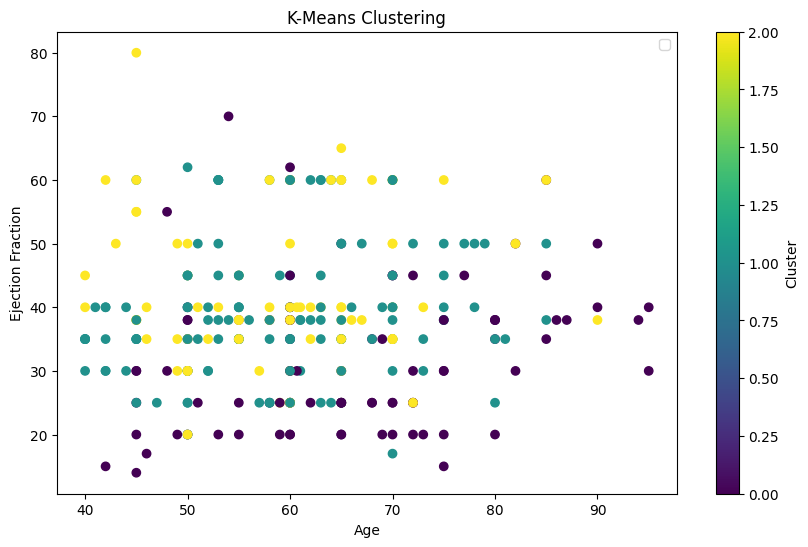

In [54]:
plt.figure(figsize=(10, 6))
plt.scatter(df['age'], df['ejection_fraction'], c=df['cluster'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Ejection Fraction')
plt.title('K-Means Clustering')
plt.colorbar(label='Cluster')
plt.legend()
plt.show()